In [2]:
#03 UHI Scores
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#results path
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

INPUT_FILE = (
    Path("results")
    / "step_02_dimension_scores.xlsx"
)

INPUT_SHEET = "Dimension_Scores"

df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

DIMENSIONS = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]

WEIGHTS = {
    "DEM_star": 0.25,
    "ECO_star": 0.25,
    "TRA_star": 0.25,
    "FUN_star": 0.25,
}

In [3]:
#Calculate the weighted contribution of each dimension
for dimension, weight in WEIGHTS.items():
    contribution_name = dimension.replace(
        "_star",
        "_contribution",
    )

    df[contribution_name] = (
        df[dimension] * weight
    )
CONTRIBUTION_COLUMNS = [
    "DEM_contribution",
    "ECO_contribution",
    "TRA_contribution",
    "FUN_contribution",
]

In [4]:
#Calculate the continuous Urban Hierarchy Index (UHI)
df["UHI"] = df[
    CONTRIBUTION_COLUMNS
].sum(axis=1)

#Standardise the UHI for visualisation and interpretation
#This transformation does not change the relative ranking of cities
df["UHI_z"] = (
    df["UHI"] - df["UHI"].mean()
) / df["UHI"].std(ddof=1)

In [5]:
#Generate overall rankings and intra-country rankings
df["UHI_rank"] = (
    df["UHI"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

df["Within_country_rank"] = (
    df.groupby("ISO3")["UHI"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

In [6]:
#Sort cities by the overall UHI ranking
df = (
    df.sort_values(
        by=["UHI_rank", "FUA_Name"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

In [7]:
#Descriptive statistics of the continuous UHI
uhi_descriptives = pd.DataFrame({
    "Statistic": [
        "N",
        "Mean",
        "Sample SD",
        "Minimum",
        "Q1",
        "Median",
        "Q3",
        "Maximum",
        "Skewness",
        "Kurtosis",
    ],

    "Value": [
        df["UHI"].count(),
        df["UHI"].mean(),
        df["UHI"].std(ddof=1),
        df["UHI"].min(),
        df["UHI"].quantile(0.25),
        df["UHI"].median(),
        df["UHI"].quantile(0.75),
        df["UHI"].max(),
        df["UHI"].skew(),
        df["UHI"].kurt(),
    ],
})

print("Descriptive statistics of the continuous UHI")
print(
    uhi_descriptives.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

Descriptive statistics of the continuous UHI
Statistic  Value
        N 56.000
     Mean -0.000
Sample SD  0.891
  Minimum -1.295
       Q1 -0.714
   Median -0.131
       Q3  0.400
  Maximum  2.251
 Skewness  0.646
 Kurtosis -0.355



In [8]:
#Create the final UHI ranking table
ranking_columns = [
    "UHI_rank",
    "Within_country_rank",
    "Country",
    "ISO3",
    "FUA_Name",
    "UHI",
    "UHI_z",
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
    "FUA_Code",
]

uhi_ranking = (
    df[ranking_columns]
    .copy()
)
print("Final UHI Ranking of the 56 Functional Urban Areas")
print(
    uhi_ranking.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)
print()

Final UHI Ranking of the 56 Functional Urban Areas
 UHI_rank  Within_country_rank        Country ISO3                 FUA_Name    UHI  UHI_z  DEM_star  ECO_star  TRA_star  FUN_star FUA_Code
        1                    1          Japan  JPN                    Tokyo  2.251  2.526     2.593     1.043     2.546     2.822   JPN01F
        2                    1  United States  USA       New York (Greater)  1.885  2.115     1.984     2.060     2.177     1.318   USA01F
        3                    2          Japan  JPN                    Osaka  1.643  1.843     1.793     0.200     2.188     2.390   JPN02F
        4                    1 United Kingdom  GBR                   London  1.529  1.716     1.454     1.535     1.823     1.303   UK001F
        5                    1         France  FRA                    Paris  1.524  1.711     1.524     1.679     1.109     1.786   FR001F
        6                    1    South Korea  KOR                    Seoul  1.390  1.560     2.165     0.830     0

In [9]:
# Save results
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_EXCEL = (
    OUTPUT_DIR
    / "step_03_UHI.xlsx"
)

OUTPUT_CSV = (
    OUTPUT_DIR
    / "step_03_UHI.csv"
)

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl",
) as writer:

    # Final UHI ranking
    uhi_ranking.to_excel(
        writer,
        sheet_name="UHI_Ranking",
        index=False,
    )

    # Descriptive statistics
    uhi_descriptives.to_excel(
        writer,
        sheet_name="UHI_Descriptives",
        index=False,
    )

# CSV
uhi_ranking.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
)

print(f"✓ Excel saved to: {OUTPUT_EXCEL}")
print(f"✓ CSV saved to: {OUTPUT_CSV}")

✓ Excel saved to: results/step_03_UHI.xlsx
✓ CSV saved to: results/step_03_UHI.csv


In [10]:
#Extract the top and bottom 10 cities by UHI
top_10 = (
    uhi_ranking
    .head(10)
    .copy()
)
bottom_10 = (
    uhi_ranking
    .tail(10)
    .copy()
)

print("Top 10 Functional Urban Areas by UHI")
print(
    top_10.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

print("Bottom 10 Functional Urban Areas by UHI")

print(
    bottom_10.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

OUTPUT_FILE = OUTPUT_DIR / "Table_Top10_UHI.xlsx"

top_10.to_excel(
    OUTPUT_FILE,
    index=False,
    sheet_name="Top10_UHI",
)

print(f"\n✓ Top 10 table saved: {OUTPUT_FILE}")

Top 10 Functional Urban Areas by UHI
 UHI_rank  Within_country_rank        Country ISO3                FUA_Name   UHI  UHI_z  DEM_star  ECO_star  TRA_star  FUN_star FUA_Code
        1                    1          Japan  JPN                   Tokyo 2.251  2.526     2.593     1.043     2.546     2.822   JPN01F
        2                    1  United States  USA      New York (Greater) 1.885  2.115     1.984     2.060     2.177     1.318   USA01F
        3                    2          Japan  JPN                   Osaka 1.643  1.843     1.793     0.200     2.188     2.390   JPN02F
        4                    1 United Kingdom  GBR                  London 1.529  1.716     1.454     1.535     1.823     1.303   UK001F
        5                    1         France  FRA                   Paris 1.524  1.711     1.524     1.679     1.109     1.786   FR001F
        6                    1    South Korea  KOR                   Seoul 1.390  1.560     2.165     0.830     0.727     1.838   KOR01F
    

In [12]:
with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl",
) as writer:
    # Complete ranking
    uhi_ranking.to_excel(
        writer,
        sheet_name="UHI_Ranking",
        index=False,
    )

    # Descriptive statistics
    uhi_descriptives.to_excel(
        writer,
        sheet_name="UHI_Descriptives",
        index=False,
    )

    # Top 10 cities
    top_10.to_excel(
        writer,
        sheet_name="Top_10_UHI",
        index=False,
    )

    # Bottom 10 cities
    bottom_10.to_excel(
        writer,
        sheet_name="Bottom_10_UHI",
        index=False,
    )

In [13]:
#Identify adjacent cities with the smallest UHI gaps
uhi_ranking["Previous_FUA"] = (
    uhi_ranking["FUA_Name"].shift(1)
)

uhi_ranking["Previous_UHI"] = (
    uhi_ranking["UHI"].shift(1)
)

uhi_ranking["Gap_from_previous"] = (
    uhi_ranking["Previous_UHI"]
    - uhi_ranking["UHI"]
)

closest_pairs = (
    uhi_ranking
    .dropna(subset=["Gap_from_previous"])
    .nsmallest(
        10,
        "Gap_from_previous",
    )
)

closest_pairs_table = closest_pairs[
    [
        "UHI_rank",
        "Previous_FUA",
        "FUA_Name",
        "Previous_UHI",
        "UHI",
        "Gap_from_previous",
    ]
].copy()

print("Adjacent FUAs with the smallest UHI gaps")
print(
    closest_pairs_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print()

Adjacent FUAs with the smallest UHI gaps
 UHI_rank Previous_FUA          FUA_Name  Previous_UHI     UHI  Gap_from_previous
       17      Houston            Berlin        0.3304  0.3303             0.0001
       55       Quebec          Changwon       -1.2645 -1.2670             0.0025
        5       London             Paris        1.5289  1.5244             0.0045
       20     Montreal Frankfurt am Main        0.1689  0.1633             0.0056
       51     Edmonton           Daejeon       -1.0087 -1.0147             0.0060
       44   Strasbourg            Ottawa       -0.7547 -0.7609             0.0062
       23   Ruhrgebiet           Fukuoka        0.0912  0.0841             0.0070
       32      Sapporo         Vancouver       -0.2649 -0.2750             0.0102
       26         Lyon        Manchester       -0.0162 -0.0267             0.0105
       50      Calgary          Edmonton       -0.9974 -1.0087             0.0113



In [15]:
#Correlations between the UHI and the four dimensions
DIMENSION_LABELS = {
    "DEM_star": "Urban Size",
    "ECO_star": "Economic Function",
    "TRA_star": "Accessibility and Connectivity",
    "FUN_star": "Functional Centrality",
}

uhi_dimension_correlations = pd.DataFrame({
    "Dimension": [
        DIMENSION_LABELS[dimension]
        for dimension in DIMENSIONS
    ],

    "Pearson_r": [
        df["UHI"].corr(
            df[dimension],
            method="pearson",
        )
        for dimension in DIMENSIONS
    ],
})
print("Pearson correlations between the UHI and the four dimensions")
print(
    uhi_dimension_correlations.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()
#检查 UHI 与四个组成维度之间的关联是否均衡，辅助判断综合指数是否明显被某一维度主导。

Pearson correlations between the UHI and the four dimensions
                     Dimension  Pearson_r
                    Urban Size      0.954
             Economic Function      0.795
Accessibility and Connectivity      0.889
         Functional Centrality      0.928



In [16]:
#Save results
OUTPUT_EXCEL = (
    OUTPUT_DIR
    / "step_03_UHI.xlsx"
)

OUTPUT_CSV = (
    OUTPUT_DIR
    / "step_03_UHI.csv"
)

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl",
) as writer:

    # Complete results
    df.to_excel(
        writer,
        sheet_name="Full_Results",
        index=False,
    )

    # Final UHI ranking
    uhi_ranking.to_excel(
        writer,
        sheet_name="UHI_Ranking",
        index=False,
    )

    # Descriptive statistics
    uhi_descriptives.to_excel(
        writer,
        sheet_name="UHI_Descriptives",
        index=False,
    )

    # Top 10 cities
    top_10.to_excel(
        writer,
        sheet_name="Top_10_UHI",
        index=False,
    )

    # Bottom 10 cities
    bottom_10.to_excel(
        writer,
        sheet_name="Bottom_10_UHI",
        index=False,
    )

    # Correlation between UHI and the four dimensions
    uhi_dimension_correlations.to_excel(
        writer,
        sheet_name="UHI_Dimension_Correlations",
        index=False,
    )

# CSV 
df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
)

print(f"✓ Excel saved to: {OUTPUT_EXCEL}")
print(f"✓ CSV saved to: {OUTPUT_CSV}")

✓ Excel saved to: results/step_03_UHI.xlsx
✓ CSV saved to: results/step_03_UHI.csv


✓ UHI distribution figure saved to: results/step_03_uhi_distribution.png


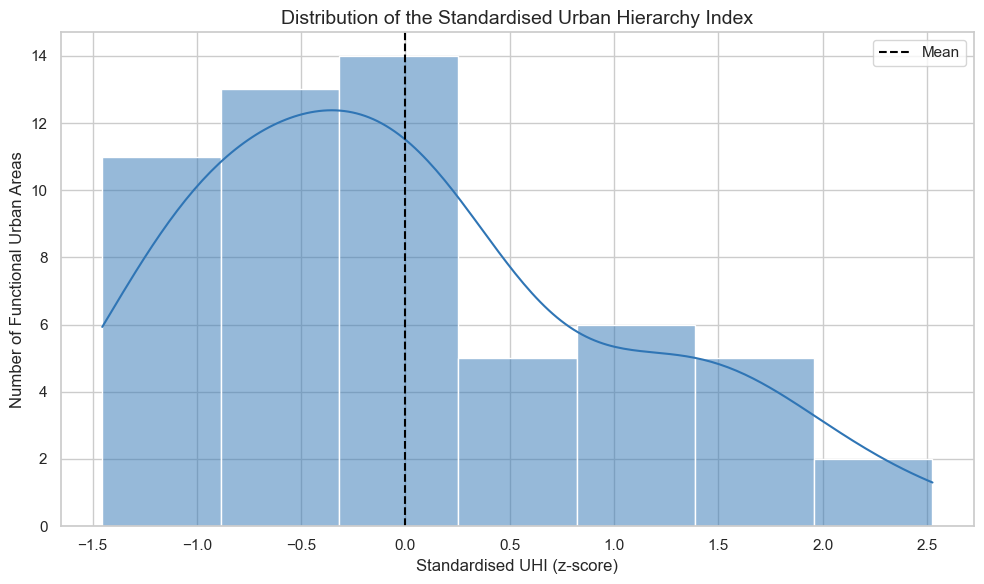

In [17]:
#Distribution of the standardised Urban Hierarchy Index
sns.set_theme(style="whitegrid")

fig, axis = plt.subplots(
    figsize=(10, 6),
)

sns.histplot(
    data=df,
    x="UHI_z",
    bins="auto",
    kde=True,
    color="#2F75B5",
    edgecolor="white",
    ax=axis,
)

# The mean of UHI_z is approximately zero
axis.axvline(
    df["UHI_z"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Mean",
)

axis.set_title(
    "Distribution of the Standardised Urban Hierarchy Index",
    fontsize=14,
)

axis.set_xlabel(
    "Standardised UHI (z-score)"
)

axis.set_ylabel(
    "Number of Functional Urban Areas"
)

axis.legend()

fig.tight_layout()

# Save figure to the current results folder
UHI_DISTRIBUTION_FIGURE = (
    OUTPUT_DIR
    / "step_03_uhi_distribution.png"
)

fig.savefig(
    UHI_DISTRIBUTION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"✓ UHI distribution figure saved to: "
    f"{UHI_DISTRIBUTION_FIGURE}"
)

plt.show()
plt.close(fig)

✓ UHI ranking figure saved to: results/step_03_uhi_ranking.png


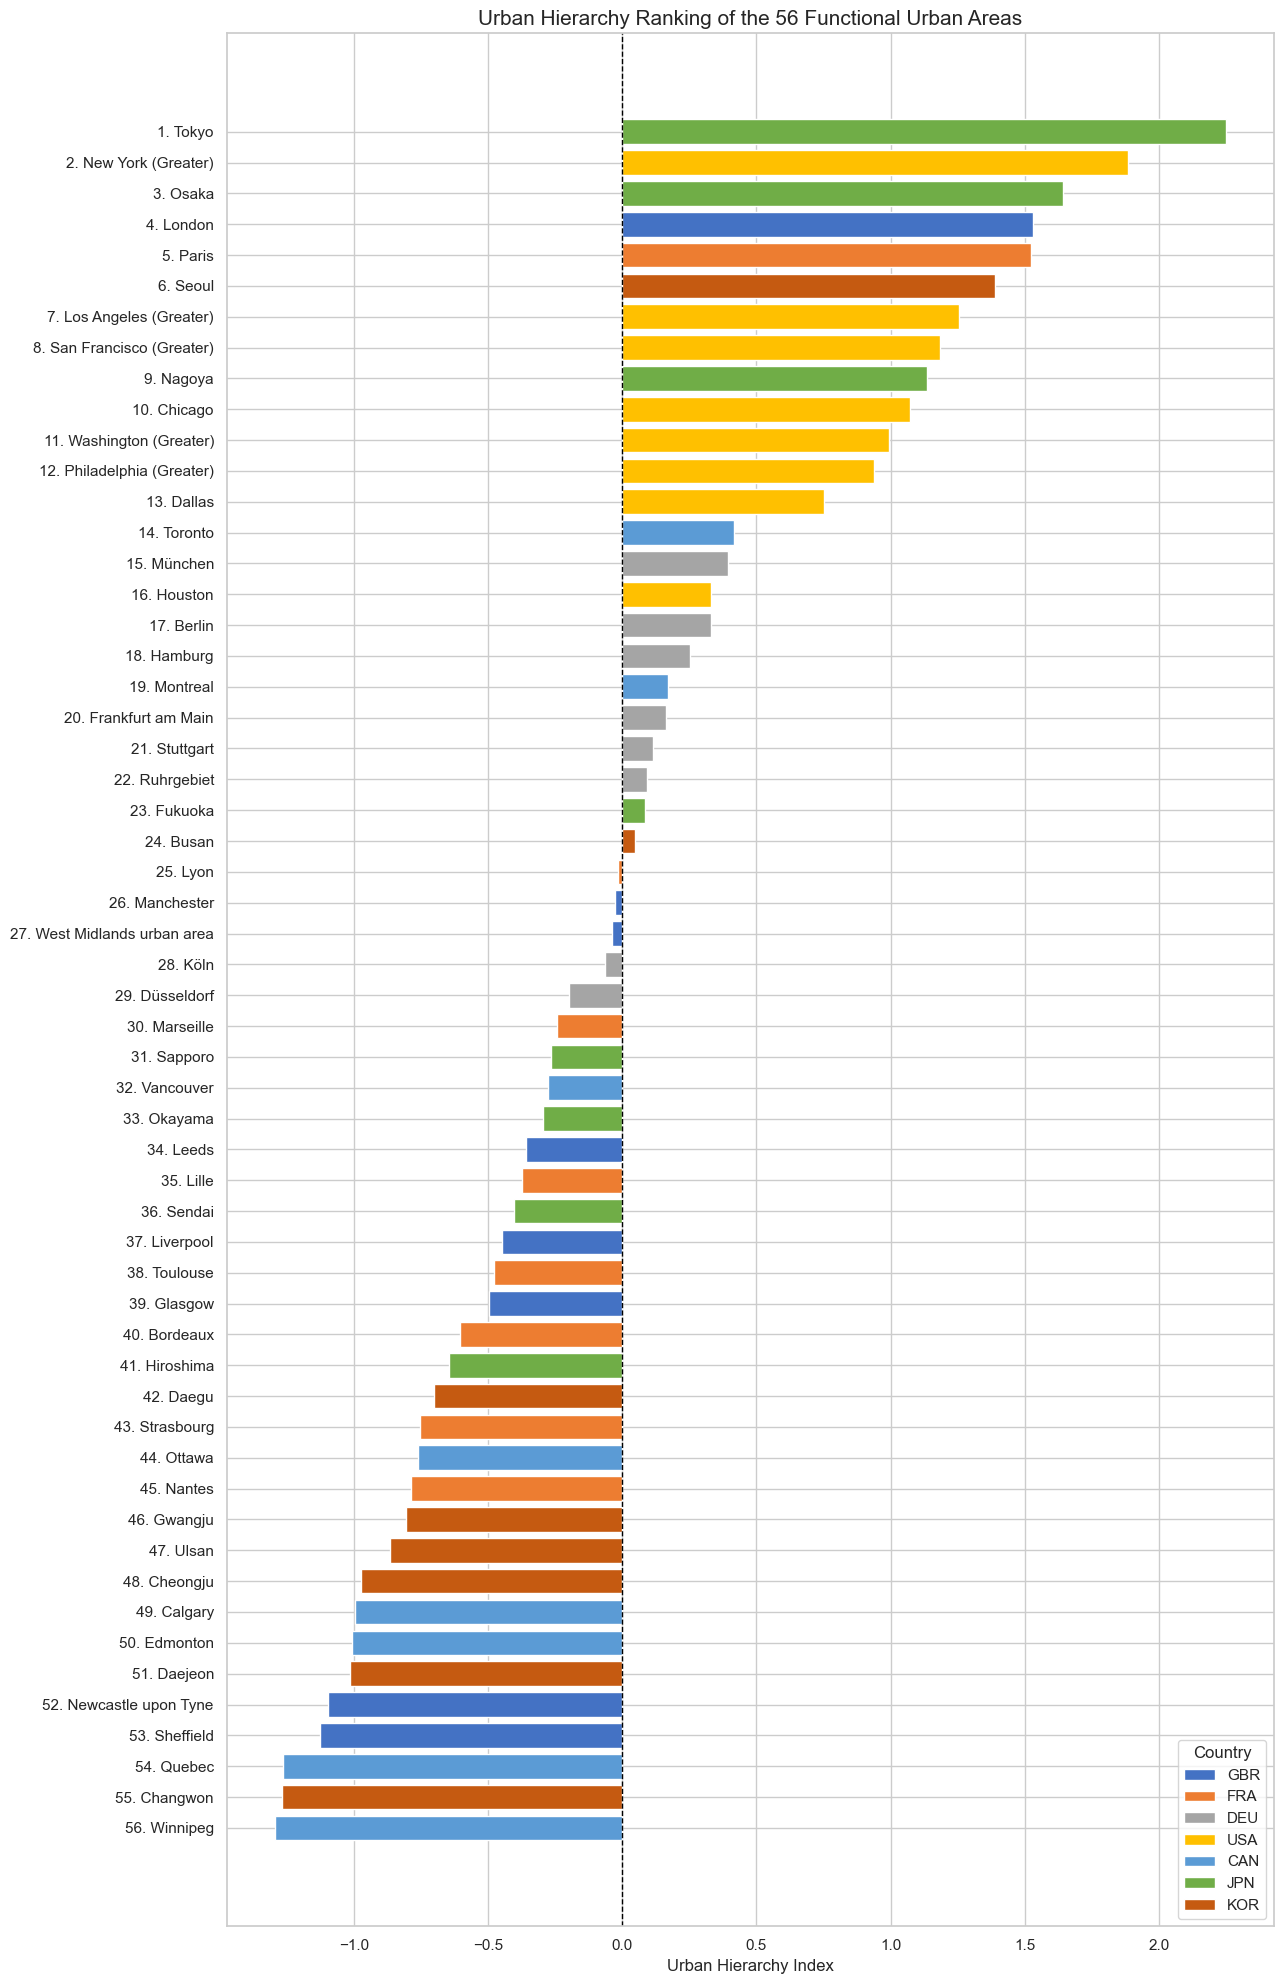

In [20]:
#Urban Hierarchy Index ranking of the 56 FUAs
from matplotlib.patches import Patch
# Sort by the final global ranking
plot_data = (
    df
    .sort_values(
        by="UHI_rank",
        ascending=False,
    )
    .copy()
)

# Display labels: Rank + City
plot_data["City_Label"] = (
    plot_data["UHI_rank"].astype(str)
    + ". "
    + plot_data["FUA_Name"]
)

# Country colours
country_palette = {
    "GBR": "#4472C4",
    "FRA": "#ED7D31",
    "DEU": "#A5A5A5",
    "USA": "#FFC000",
    "CAN": "#5B9BD5",
    "JPN": "#70AD47",
    "KOR": "#C55A11",
}

bar_colours = plot_data["ISO3"].map(country_palette)

# Create figure
fig, axis = plt.subplots(
    figsize=(13, 20),
)

axis.barh(
    plot_data["City_Label"],
    plot_data["UHI"],
    color=bar_colours,
)

# Mean reference line
axis.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axis.set_title(
    "Urban Hierarchy Ranking of the 56 Functional Urban Areas",
    fontsize=15,
)

axis.set_xlabel(
    "Urban Hierarchy Index"
)

axis.set_ylabel("")

# Country legend
legend_handles = [
    Patch(
        facecolor=colour,
        label=country
    )
    for country, colour in country_palette.items()
]

axis.legend(
    handles=legend_handles,
    title="Country",
    loc="lower right",
)

fig.tight_layout()

# Save figure
UHI_RANKING_FIGURE = (
    OUTPUT_DIR
    / "step_03_uhi_ranking.png"
)

fig.savefig(
    UHI_RANKING_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"✓ UHI ranking figure saved to: "
    f"{UHI_RANKING_FIGURE}"
)

plt.show()
plt.close(fig)

✓ Contribution figure saved to: results/step_03_top15_dimension_contributions.png


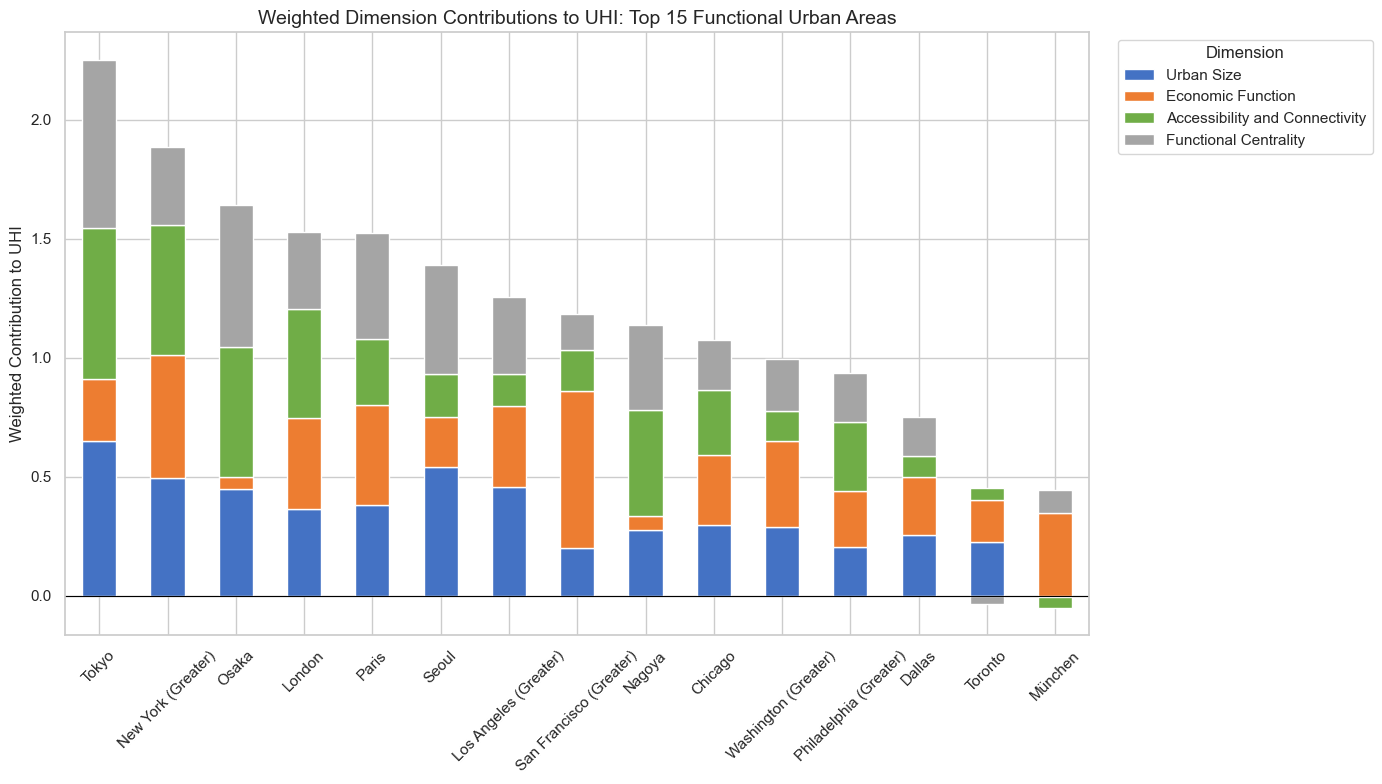

In [21]:
#Weighted dimension contributions for the top 15 FUAs
# Explicitly select the top 15 cities by final UHI ranking
top_15 = (
    df.sort_values(
        by="UHI_rank",
        ascending=True,
    )
    .head(15)
    .copy()
)
# Prepare weighted contribution data
contribution_plot = (
    top_15
    .set_index("FUA_Name")[
        CONTRIBUTION_COLUMNS
    ]
    .rename(
        columns={
            "DEM_contribution": "Urban Size",
            "ECO_contribution": "Economic Function",
            "TRA_contribution": "Accessibility and Connectivity",
            "FUN_contribution": "Functional Centrality",
        }
    )
)

# Create stacked bar chart
fig, axis = plt.subplots(
    figsize=(14, 8),
)

contribution_plot.plot(
    kind="bar",
    stacked=True,
    ax=axis,
    color=[
        "#4472C4",
        "#ED7D31",
        "#70AD47",
        "#A5A5A5",
    ],
)

axis.axhline(
    y=0,
    color="black",
    linewidth=0.8,
)

axis.set_title(
    "Weighted Dimension Contributions to UHI: Top 15 Functional Urban Areas",
    fontsize=14,
)

axis.set_xlabel("")
axis.set_ylabel("Weighted Contribution to UHI")

axis.tick_params(
    axis="x",
    rotation=45,
)

axis.legend(
    title="Dimension",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
# Save figure
CONTRIBUTION_FIGURE = (
    OUTPUT_DIR
    / "step_03_top15_dimension_contributions.png"
)

fig.savefig(
    CONTRIBUTION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"✓ Contribution figure saved to: "
    f"{CONTRIBUTION_FIGURE}"
)

plt.show()
plt.close(fig)